In [14]:
from __future__ import  absolute_import
import os

import tensorflow as tf
from tensorflow.python.framework import ops
import sonnet as snt
import numpy as np 
import matplotlib.pyplot as plt

In [15]:
print("TensorFlow version {}".format(tf.__version__))
print("Sonnet version {}".format(snt.__version__))

TensorFlow version 1.15.0
Sonnet version 1.36


In [16]:
def gaussian_mask(u, s, d, R, C):
    """
    u: tf.Tensor, center of first Gaussian
    s: tf.Tensor, standard deviation of Gaussian
    d: tf.Tensor, shiftbetween Gaussian center
    R: int, number of rows in the mask, there is one Gaussian per row
    C: int, number of cols in the mask
    """
    # indices to create center
    R = tf.to_float(tf.reshape(tf.range(R), (1,1,R))) 
    # create an array type int [0, 1,.., R-1] than reshape to (1, 1, R) and change to float
    C = tf.to_float(tf.reshape(tf.range(C), (1,C,1)))
    centres = u[np.newaxis, :, np.newaxis] + R * d
    column_centres = C-centres
    mask = tf.exp(-0.5 * tf.square(column_centres/s))
    # add eps for numerical stability
    normalised_maks = mask/(tf.reduce_sum(mask, 1, keep_dims=True) + 1e-8)
    return normalised_maks

In [17]:
def gaussian_glimpse(img_tensor, transform_params, crop_size):
    """
    :param img_tensor: tf.Tensor of size (batch_size, Height, Width, channels)
    :param transform_params: tf.Tensor of size (batch_size, 6), where params are  (mean_y, std_y, d_y, mean_x, std_x, d_x) specified in pixels.
    :param crop_size): tuple of 2 ints, size of the resulting crop
    """
    # parse arguments
    h, w = crop_size
    H, W = img_tensor.shape.as_list()[1:3]
    split_ax = transform_params.shape.ndims -1
    uy, sy, dy, ux, sx, dx = tf.split(transform_params, 6, split_ax)
    # create Gaussian masks, one for each axis
    Ay = gaussian_mask(uy, sy, dy, h, H)
    Ax = gaussian_mask(ux, sx, dx, w, W)
    # extract glimpse
    glimpse = tf.matmul(tf.matmul(Ay, img_tensor, adjoint_a=True), Ax)
    return glimpse

In [18]:
def spatial_transformer(img_tensor, transform_params, crop_size):
    """
    img_tensor: tf.Tensor of size(batch_size, Height, Width, channels)
    transform_params: tf.Tensor of size(batch_size, 4) where params are  (scale_y, shift_y, scale_x, shift_x)
    crop_size: tuple of 2 ints, size of resulting crop
    """
    constrains = snt.AffineWarpConstraints.no_shear_2d()
    img_size = img_tensor.shape.as_list()[1:]
    warper = snt.AffineGridWarper(img_size, crop_size, constrains)
    grid_coords = warper(transform_params)
    glimpse = tf.contrib.resampler.resampler(img_tensor[..., tf.newaxis], grid_coords)
    return glimpse

In [19]:
img_size = 10, 10
glimpse_size = 5, 5

# Create random image with a square
x = abs(np.random.randn(1, *img_size)) * 0.3
x[0, 3:6, 3:6] = 1
crop = x[0, 2:7, 2:7]

In [20]:
ops.reset_default_graph()

# placeholders
tx = tf.placeholder(tf.float32, x.shape, 'image')
tu = tf.placeholder(tf.float32, [1], 'u')
ts = tf.placeholder(tf.float32, [1], 's')
td = tf.placeholder(tf.float32, [1], 'd')
stn_params = tf.placeholder(tf.float32, [1, 4], 'stn_params')

In [21]:
# Gaussian Attention
gaussian_att_params = tf.concat([tu, ts, td, tu, ts, td], -1)
gaussian_glimpse_expr = gaussian_glimpse(tx, gaussian_att_params, glimpse_size)

# Spatial Transformer
stn_glimpse_expr = spatial_transformer(tx, stn_params, glimpse_size)

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



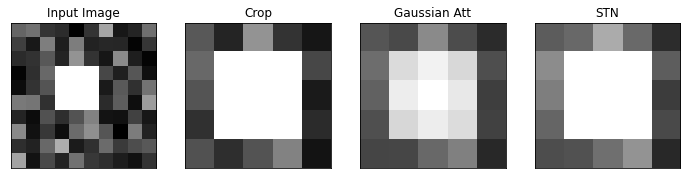

In [22]:
sess = tf.Session()

# extract a Gaussian glimpse
u = 2
s = .5
d = 1
u, s, d = (np.asarray([i]) for i in (u, s, d))
gaussian_crop = sess.run(gaussian_glimpse_expr, feed_dict={tx: x, tu: u, ts: s, td: d})

# extract STN glimpse
transform = [.4, -.1, .4, -.1]
transform = np.asarray(transform).reshape((1, 4))
stn_crop = sess.run(stn_glimpse_expr, {tx: x, stn_params: transform})


# plots
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

titles = ['Input Image', 'Crop', 'Gaussian Att', 'STN']
imgs = [x, crop, gaussian_crop, stn_crop]
for ax, title, img in zip(axes, titles, imgs):
    ax.imshow(img.squeeze(), cmap='gray', vmin=0., vmax=1.)
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)